Value Range ...... Shape Description
- 0.0 - 0.2 ...... Highly Elongated
- 0.2 - 0.4 ...... Elongated
- 0.4 - 0.6 ...... Intermediate / Oval
- 0.6 - 0.8 ...... Round / Ellipsoid
- 0.8 - 1.0 ...... Spherical

In [8]:
import os
import glob
import pandas as pd
pd.set_option('future.no_silent_downcasting', True)

main_folder_path = r"E:\DATA_Myelomy"

# --- STEP 1: LOAD RAW LESIONS (NOT AGGREGATED) ---
all_lesions = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)
    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))

    if csv_files:
        csv_path = csv_files[0]
        # Load all lesions for this patient
        df_lesions = pd.read_csv(csv_path).filter(like="shape")
        # Add the patient ID so the model knows which lesions belong together
        df_lesions['patient_id'] = folder_name
        all_lesions.append(df_lesions)

# Combine into one big dataframe where 1 row = 1 lesion
df_all_lesions = pd.concat(all_lesions, ignore_index=True)

# --- STEP 2: MERGE WITH CLINICAL DATA ---
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

# Merge clinical stage into the lesion list
data_mm = pd.merge(df_all_lesions, clinical_df[['Patient ID', 'Stage']],
                    left_on='patient_id', right_on='Patient ID')

# Ensure Stage is treated as a category for the model
data_mm = data_mm.dropna(subset=['Stage'])
data_mm['Stage'] = data_mm['Stage'].astype(int)

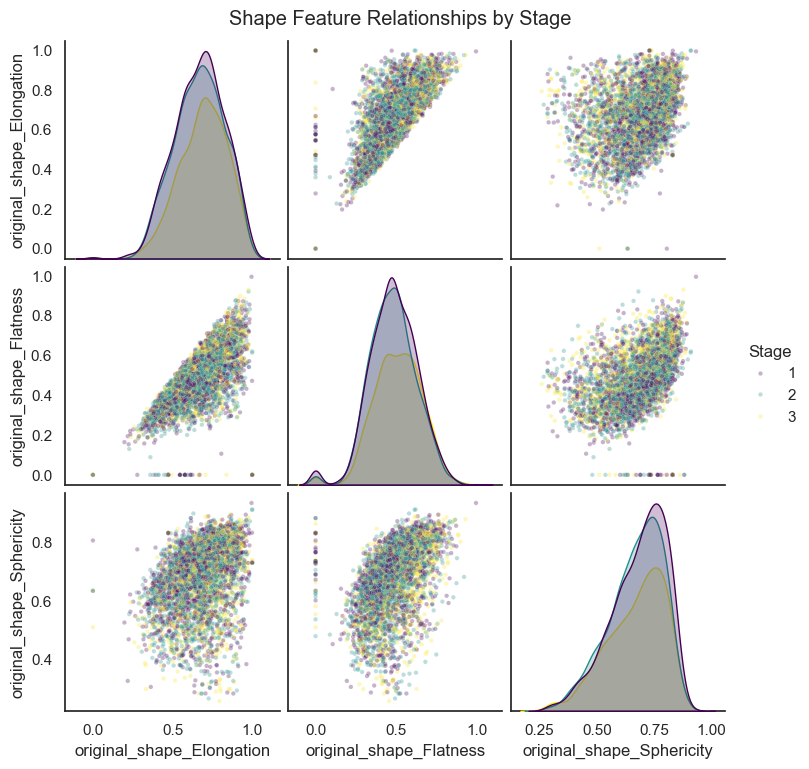

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of the most 'informative' shape features
shape_subset = [
    'original_shape_Elongation',
    'original_shape_Flatness',
    'original_shape_Sphericity'
]

# 1. Pair Plot: See how every feature relates to the others
# This is the best way to spot clusters visually
pp = sns.pairplot(
    data_mm,
    vars=shape_subset,
    hue='Stage',
    palette='viridis',
    plot_kws={'alpha': 0.3, 's': 10}
)
pp.fig.suptitle("Shape Feature Relationships by Stage", y=1.02)
plt.show()

In [14]:
# FOR ALL PATIENTS
main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col]

        shape_features_stats[f"{col}_mean"]   = x.mean()
        shape_features_stats[f"{col}_median"] = x.median()

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)

clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
data = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID')

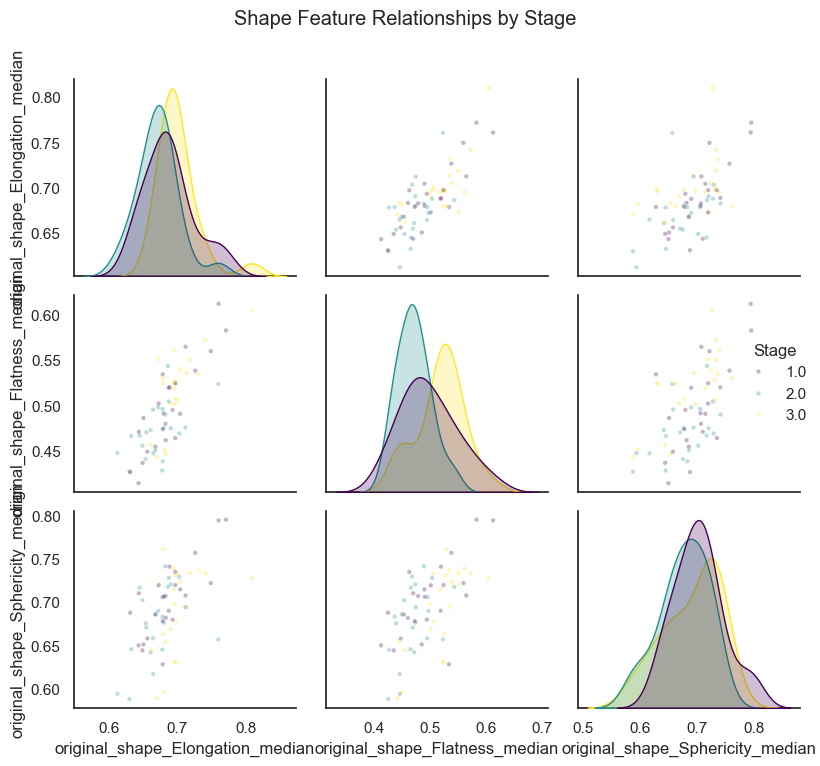

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of the most 'informative' shape features
shape_subset = [
    'original_shape_Elongation_median',
    'original_shape_Flatness_median',
    'original_shape_Sphericity_median'
]

pp = sns.pairplot(
    data,
    vars=shape_subset,
    hue='Stage',
    palette='viridis',
    plot_kws={'alpha': 0.3, 's': 10}
)
pp.fig.suptitle("Shape Feature Relationships by Stage", y=1.02)
plt.tight_layout()
plt.show()

# PCA on created shape features

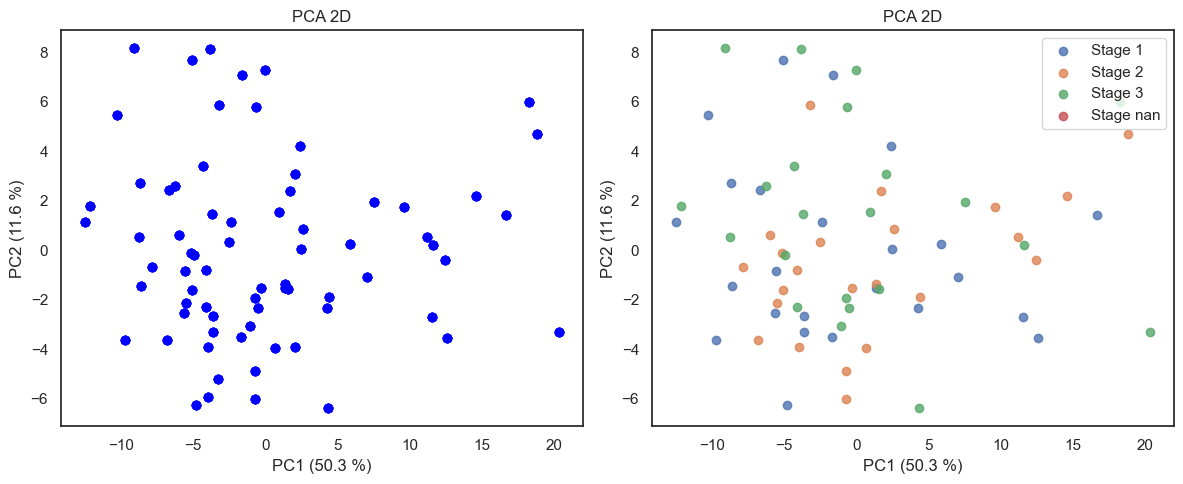

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col]

        shape_features_stats[f"{col}_mean"]   = x.mean()
        shape_features_stats[f"{col}_median"] = x.median()
        shape_features_stats[f"{col}_std"]    = x.std()
        shape_features_stats[f"{col}_var"]    = x.var()
        shape_features_stats[f"{col}_cv"]     = x.std() / x.mean()     # coefficient of variation
        shape_features_stats[f"{col}_range"]  = x.max() - x.min()
        shape_features_stats[f"{col}_min"]    = x.min()
        shape_features_stats[f"{col}_max"]    = x.max()

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
df_merged = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID')

df_features = df_merged.drop(columns=['patient_id', 'Stage', 'Patient ID'])
stage = df_merged['Stage']

df_scaled = StandardScaler().fit_transform(df_features)

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(12, 5))
for s in sorted(stage.unique()):
    idx = stage == s
    plt.subplot(122)
    plt.scatter(df_pca[idx, 0], df_pca[idx, 1], label=f"Stage {s}",alpha=0.8)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
    plt.title(f"PCA 2D")
    plt.legend()

    plt.subplot(121)
    plt.scatter(df_pca[:, 0], df_pca[:, 1], color="blue")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
    plt.title(f"PCA 2D")

plt.tight_layout()
plt.show()

# PCA on created shape distribution features

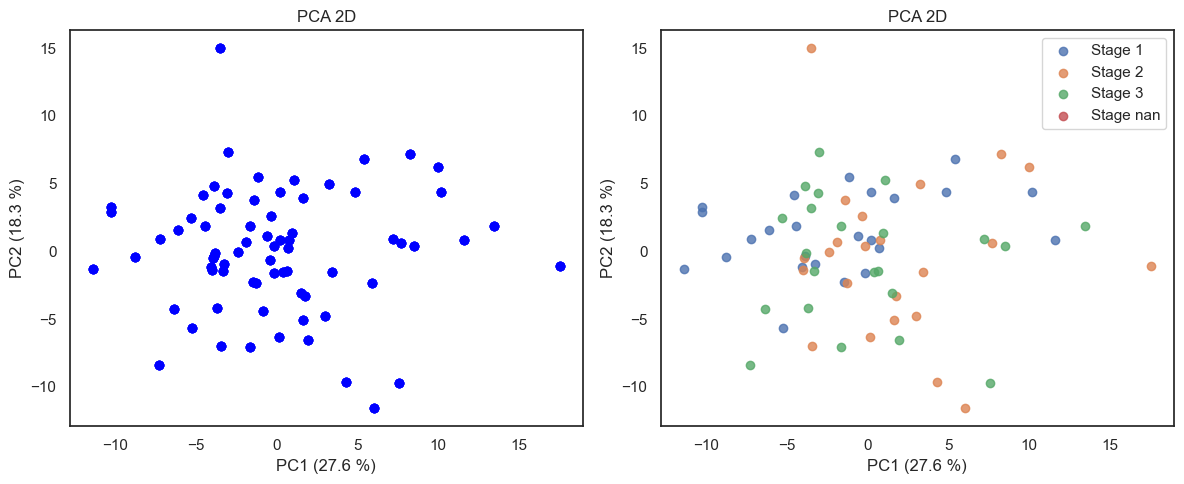

In [26]:
import numpy as np

main_folder_path = r"E:\DATA_Myelomy"

all_patients = []
for folder_name in os.listdir(main_folder_path):
    patient_folder_path = os.path.join(main_folder_path, folder_name)

    csv_files = glob.glob(os.path.join(patient_folder_path, "*individual_lesion_features*.csv"))
    csv_path = csv_files[0]  # choose first one (does not matter, shape features are same for every image)

    df = pd.read_csv(csv_path).filter(like="shape")

    shape_features_stats = {"patient_id": folder_name}
    for col in df.columns:
        x = df[col].dropna()

        from scipy.stats import skew, kurtosis
        shape_features_stats[f"{col}_skewness"] = skew(x)
        shape_features_stats[f"{col}_kurtosis"] = kurtosis(x)

        shape_features_stats[f"{col}_percentile10"] = x.quantile(0.10)
        shape_features_stats[f"{col}_percentile25"] = x.quantile(0.25)
        shape_features_stats[f"{col}_percentile75"] = x.quantile(0.75)
        shape_features_stats[f"{col}_percentile90"] = x.quantile(0.90)
        shape_features_stats[f"{col}_IQR"] = x.quantile(0.75) - x.quantile(0.25)  # InterQuartileRange (P75-P25)

        hist, _ = np.histogram(x, bins=20)
        hist = hist / hist.sum()
        hist = hist[hist > 0]

        from scipy.stats import entropy
        shape_features_stats[f"{col}_entropy"] = entropy(hist)

    all_patients.append(shape_features_stats)
df_final = pd.DataFrame(all_patients)

pd.set_option('future.no_silent_downcasting', True)
clinical_df = pd.read_csv(r"E:\Clinical_data\Table_clinical_data.csv", encoding="cp1252")
clinical_df['Stage'] = clinical_df['ISS classification'].replace({'Stage 1': 1, 'Stage 2': 2, 'Stage 3': 3})

numeric_features = df_final.select_dtypes(include=['number']).columns
df_merged = pd.merge(df_final, clinical_df[['Patient ID', 'Stage']], left_on='patient_id', right_on='Patient ID')

df_features = df_merged.drop(columns=['patient_id', 'Stage', 'Patient ID'])
stage = df_merged['Stage']

df_scaled = StandardScaler().fit_transform(df_features)

pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_scaled)

plt.figure(figsize=(12, 5))
for s in sorted(stage.unique()):
    idx = stage == s
    plt.subplot(122)
    plt.scatter(df_pca[idx, 0], df_pca[idx, 1], label=f"Stage {s}",alpha=0.8)
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
    plt.title(f"PCA 2D")
    plt.legend()

    plt.subplot(121)
    plt.scatter(df_pca[:, 0], df_pca[:, 1], color="blue")
    plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
    plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")
    plt.title(f"PCA 2D")

plt.tight_layout()
plt.show()

outlierová analýza